Harris: dia nandainnya lumayan gede areanya, nggak bisa detect edge lengkung  
SubPix: dia nandainnya langsung di satu titik tepat, detect dengan titik-titik

In [38]:
import numpy as np 
import matplotlib.pyplot as plt
import cv2
import os

(-0.5, 1.5, 63.5, -0.5)

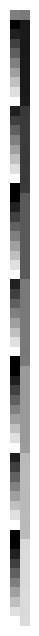

In [29]:
img = cv2.imread('chess.png')

gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

harris = cv2.cornerHarris(gray, 2, 5, 0.04)

no_SubPix = img.copy()
no_SubPix[harris > 0.01 * harris.max()] = [0, 0, 255]

_, thres = cv2.threshold(harris, 0.01 * harris.max(), 255, 0)
thres = np.uint8(thres)

_, _, _, centroid = cv2.connectedComponentsWithStats(thres)

centroid = np.float32(centroid)
criteria = [cv2.TERM_CRITERIA_MAX_ITER + cv2.TERM_CRITERIA_EPS, 100, 0.01]
enhanced_corner = cv2.cornerSubPix(
    harris, centroid, (5,5), (-1,-1), criteria
)

SubPix = img.copy()

centroid = np.uint16(centroid)
for centroid in centroid:
    x = centroid[0]
    y = centroid[1]
    SubPix[y,x] = [0,0,255]

enhanced_corner = np.uint16(enhanced_corner)
for corner in enhanced_corner:
    x = corner[0]
    y = corner[1]
    SubPix[y,x] = [255,0,0]
     

plt.figure(figsize=(8,8))
plt.imshow(enhanced_corner, "gray")
plt.axis(False)

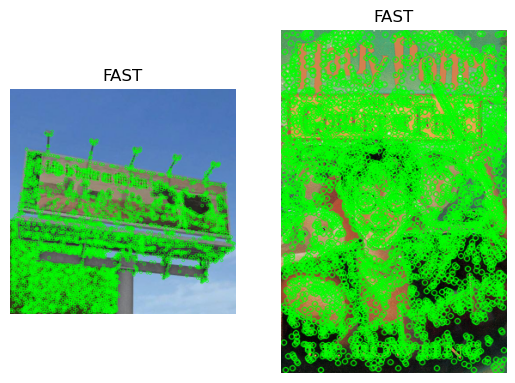

In [49]:
dir = 'images'

for i, imageName in enumerate(os.listdir(dir)):
    image = cv2.imread(
        dir + '/' + imageName
    )
    
    fast = cv2.FastFeatureDetector_create()  # ini ndak kebaca karena katane kebacane di C++
    
    keypoint = fast.detect(image, None)
    fast_res = image.copy()
    cv2.drawKeypoints(image, keypoint, fast_res, [0,255,0])
    
    fast_res = cv2.cvtColor(fast_res, cv2.COLOR_BGR2RGB)
    
    plt.subplot(1, 2, i+1)
    plt.imshow(fast_res)
    plt.axis(False)
    plt.title("FAST")
plt.show()

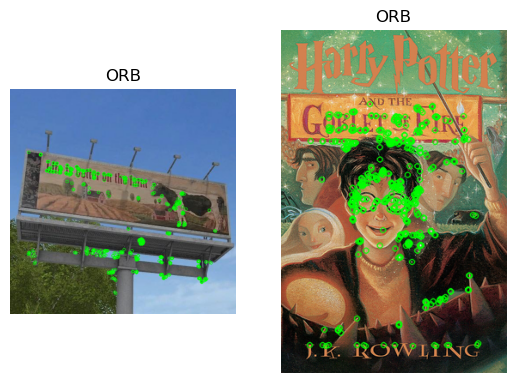

In [50]:
dir = 'images'

for i, imageName in enumerate(os.listdir(dir)):
    image = cv2.imread(
        dir + '/' + imageName
    )
    
    orb = cv2.ORB_create()
    
    keypoint = orb.detect(image, None)
    orb_res = image.copy()
    cv2.drawKeypoints(image, keypoint, orb_res, [0,255,0])
    
    orb_res = cv2.cvtColor(orb_res, cv2.COLOR_BGR2RGB)
    
    plt.subplot(1, 2, i+1)
    plt.imshow(orb_res)
    plt.axis(False)
    plt.title("ORB")
plt.show()